<a href="https://colab.research.google.com/github/muosaVip/Data-Science/blob/main/Diabetes_Readmission_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ==========================================================
# مشروع علم بيانات طبي
# تحليل بيانات مرضى السكري والتنبؤ بخطر إعادة التنويم
# ملف البيانات: diabetic_data.csv
# ==========================================================

# ----------------------------------------------------------
# 1) استيراد المكتبات الأساسية
# ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تحسين شكل الرسوم
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [9]:
# ----------------------------------------------------------
# 2) قراءة ملف البيانات من Google Colab
# تأكد أن الملف مرفوع بنفس الاسم
# ----------------------------------------------------------
df = pd.read_csv("diabetic_data.csv")

# عرض أول 5 صفوف
print("أول 5 صفوف من البيانات:")
print(df.head())

أول 5 صفوف من البيانات:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No     

In [10]:
# ----------------------------------------------------------
# 3) استبدال الرموز الغريبة ? بقيم مفقودة NaN
# لأن بعض الملفات تستخدم ? بدل البيانات الناقصة
# ----------------------------------------------------------
df.replace("?", np.nan, inplace=True)

# ----------------------------------------------------------
# 4) حساب نسبة القيم المفقودة في كل عمود
# ----------------------------------------------------------
missing_percent = df.isnull().mean() * 100

print("\nنسبة القيم المفقودة لكل عمود:")
print(missing_percent.sort_values(ascending=False))

# ----------------------------------------------------------
# 5) حذف الأعمدة التي تزيد نسبة النقص فيها عن 40%
# مثال: weight غالباً يحتوي نقص كبير
# ----------------------------------------------------------
columns_to_drop = missing_percent[missing_percent > 40].index

df.drop(columns=columns_to_drop, inplace=True)

print("\nالأعمدة المحذوفة بسبب كثرة النقص:")
print(list(columns_to_drop))



نسبة القيم المفقودة لكل عمود:
weight                      96.858479
max_glu_serum               94.746772
A1Cresult                   83.277322
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
patient_nbr                  0.000000
time_in_hospital             0.000000
admission_source_id          0.000000
num_lab_procedures           0.000000
encounter_id                 0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
gender                       0.000000
age                          0.000000
number_inpatient             0.000000
number_emergency             0.000000
number_outpatient            0.000000
num_medications              0.000000
num_procedures               0.000000
number_diagnoses             0.000000
metformin                    0.000000
repaglinide        


توزيع عمود الهدف:
readmitted
0    90409
1    11357
Name: count, dtype: int64


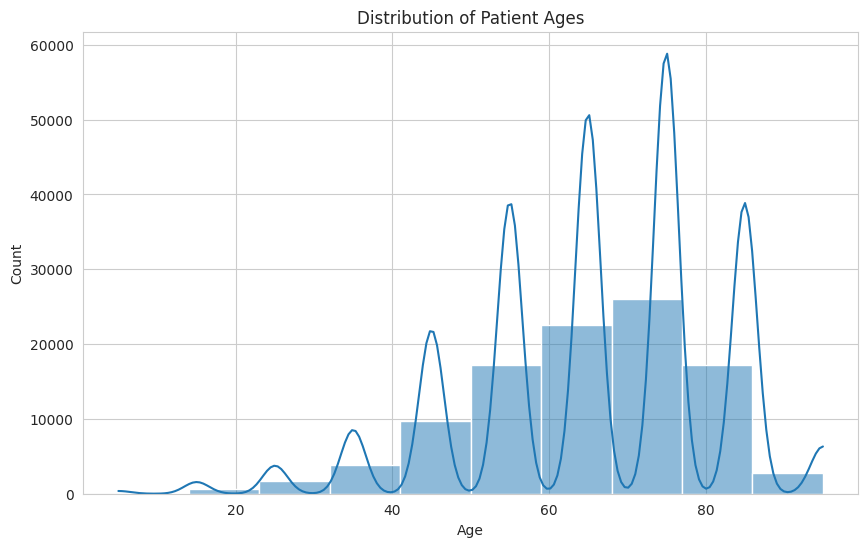

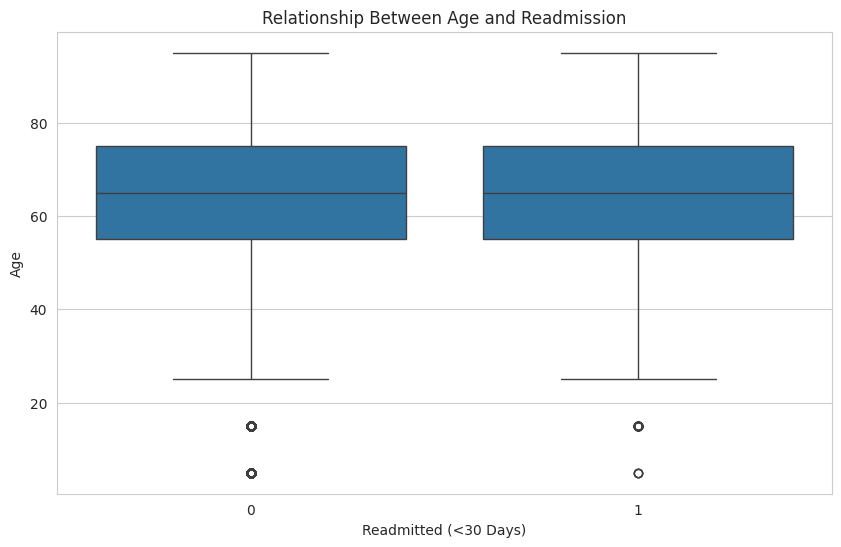


شكل البيانات النهائي:
(101766, 45)

أسماء الأعمدة النهائية:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'age_numeric']


In [11]:
# ----------------------------------------------------------
# 6) حذف الأعمدة الإدارية غير المفيدة للنموذج
# لأنها مجرد أرقام تعريفية وليست عوامل صحية
# ----------------------------------------------------------
unnecessary_cols = ["encounter_id", "patient_nbr"]

# حذف فقط إذا كانت موجودة
df.drop(columns=[col for col in unnecessary_cols if col in df.columns],
        inplace=True)

# ----------------------------------------------------------
# 7) تحويل عمود الهدف readmitted إلى أرقام
# إذا كانت <30  تصبح 1
# غير ذلك تصبح 0
# الهدف: إعادة تنويم سريع خلال أقل من 30 يوم
# ----------------------------------------------------------
df["readmitted"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

print("\nتوزيع عمود الهدف:")
print(df["readmitted"].value_counts())

# ----------------------------------------------------------
# 8) تحويل عمود العمر من فئات نصية إلى أرقام تقريبية
# مثل [70-80) تصبح 75
# لتسهيل الرسم والتحليل
# ----------------------------------------------------------
age_map = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age_numeric"] = df["age"].map(age_map)

# ----------------------------------------------------------
# 9) رسم توزيع أعمار المرضى
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

sns.histplot(df["age_numeric"], bins=10, kde=True)

plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ----------------------------------------------------------
# 10) رسم العلاقة بين العمر وإعادة التنويم
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

sns.boxplot(
    x="readmitted",
    y="age_numeric",
    data=df
)

plt.title("Relationship Between Age and Readmission")
plt.xlabel("Readmitted (<30 Days)")
plt.ylabel("Age")
plt.show()

# ----------------------------------------------------------
# 11) معلومات نهائية عن البيانات بعد التنظيف
# ----------------------------------------------------------
print("\nشكل البيانات النهائي:")
print(df.shape)

print("\nأسماء الأعمدة النهائية:")
print(df.columns.tolist())

تم تحويل الأعمدة النصية التالية إلى أرقام:
['race', 'gender', 'age', 'payer_code', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Accuracy Score:
0.8885

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.67      0.00      0.00      2271

    accuracy                           0.89     20354
   macro avg       0.78      0.50      0.47     20354
weighted avg       0.86      0.89      0.84     20354


Top 10 Important Features:
                     Feature  Importance
13          number_inpatient    0

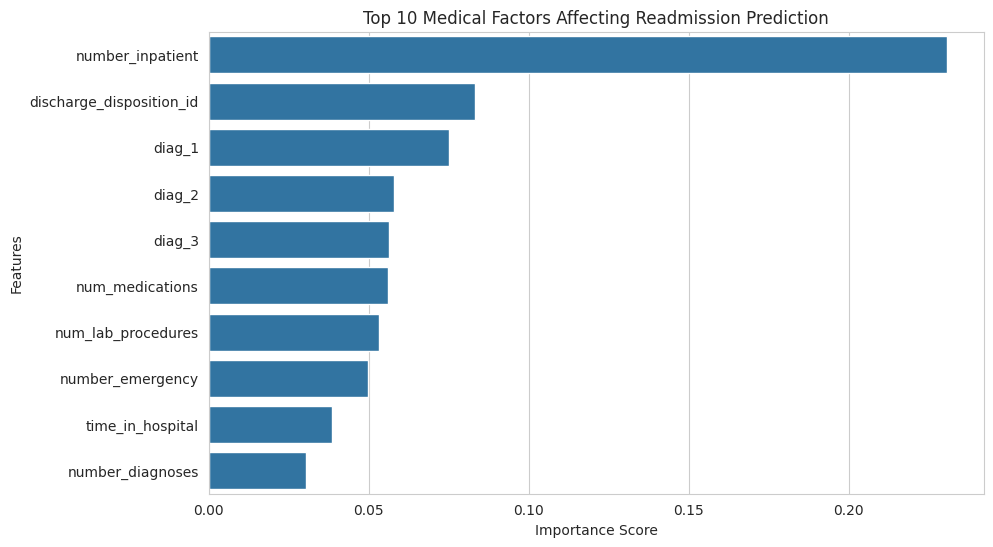

In [15]:
# ==========================================================
# مشروع علم بيانات طبي
# التنبؤ بإعادة تنويم مرضى السكري باستخدام Random Forest
# يفترض أن البيانات تم تنظيفها سابقاً ومخزنة في df
# ==========================================================

# ----------------------------------------------------------
# 1) استيراد المكتبات
# ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# تحسين الرسوم
sns.set_style("whitegrid")

# ----------------------------------------------------------
# 2) التأكد من وجود عمود الهدف readmitted
# يجب أن يكون:
# 1 = إعادة تنويم أقل من 30 يوم
# 0 = غير ذلك
# ----------------------------------------------------------

# إذا لم يتم تحويله مسبقاً، نفذ التالي:
# df["readmitted"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

# ----------------------------------------------------------
# 3) تحويل الأعمدة النصية المتبقية إلى أرقام
# باستخدام LabelEncoder
# ----------------------------------------------------------

le = LabelEncoder()

# نسخ البيانات لتجنب تعديل الأصل
df_model = df.copy()

# البحث عن الأعمدة النصية
categorical_cols = df_model.select_dtypes(include="object").columns

# تحويل كل عمود نصي إلى أرقام
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("تم تحويل الأعمدة النصية التالية إلى أرقام:")
print(list(categorical_cols))

# ----------------------------------------------------------
# 4) تحديد المدخلات X والهدف y
# ----------------------------------------------------------

X = df_model.drop("readmitted", axis=1)
y = df_model["readmitted"]

# ----------------------------------------------------------
# 5) تقسيم البيانات إلى تدريب واختبار
# 80% تدريب - 20% اختبار
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ----------------------------------------------------------
# 6) إنشاء نموذج Random Forest
# ----------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,      # عدد الأشجار
    max_depth=10,          # عمق الشجرة
    random_state=42
)

# تدريب النموذج
model.fit(X_train, y_train)

# ----------------------------------------------------------
# 7) التنبؤ على بيانات الاختبار
# ----------------------------------------------------------

y_pred = model.predict(X_test)

# ----------------------------------------------------------
# 8) تقييم النموذج
# ----------------------------------------------------------

acc = accuracy_score(y_test, y_pred)

print("\n===================================")
print("Accuracy Score:")
print(round(acc, 4))
print("===================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# شرح سريع:
# Precision = دقة التوقعات الإيجابية
# Recall    = قدرة النموذج على اكتشاف الحالات الصحيحة
# F1-score  = توازن بين Precision و Recall

# ----------------------------------------------------------
# 9) أهمية الميزات Feature Importance
# ما أكثر العوامل المؤثرة في القرار؟
# ----------------------------------------------------------

importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# ترتيب تنازلي
feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

# أخذ أفضل 10 عوامل
top10 = feature_df.head(10)

print("\nTop 10 Important Features:")
print(top10)

# ----------------------------------------------------------
# 10) الرسم البياني لأفضل 10 عوامل
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Medical Factors Affecting Readmission Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()